### evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
import os


df = pd.read_csv('../data/plants_final.csv')

In [3]:
model_files = [
    '../models/matcher_model_final.keras',
    '../models/encoders.pkl',
    '../models/scaler.pkl',
    '../models/feature_cols.pkl',
    '../models/similarity_kmeans.pkl',
    '../models/similarity_scaler.pkl',
    '../models/similarity_features.pkl',
]

print("checking files:")
for f in model_files:
    exists = os.path.exists(f)
    print(f"  {'(Y)' if exists else '(X)'} {f}")


checking files:
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/matcher_model_final.keras
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/encoders.pkl
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/scaler.pkl
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/feature_cols.pkl
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/similarity_kmeans.pkl
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/similarity_scaler.pkl
  (Y) /Users/gabe/Desktop/John Bryce/Plearn - Final Project/models/similarity_features.pkl


In [4]:
best_model = tf.keras.models.load_model('../models/matcher_model_final.keras')

with open('../models/encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

In [5]:

with open('../models/similarity_kmeans.pkl', 'rb') as f:
    kmeans = pickle.load(f)

with open('../models/similarity_scaler.pkl', 'rb') as f:
    scaler_sim = pickle.load(f)

with open('../models/similarity_features.pkl', 'rb') as f:
    similarity_features = pickle.load(f)

In [6]:
print("\nall loaded:")
print(f"  dataset: {df.shape}")
print(f"  model 1 features: {len(feature_cols)}")
print(f"  model 2 features: {len(similarity_features)}")
print(f"  model 2 clusters: {df['cluster'].nunique()}")

all loaded:
  dataset: (936, 70)
  model 1 features: 46
  model 2 features: 23
  model 2 clusters: 15


### Matcher Model

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

cat_cols = ['watering', 'sunlight_primary', 'care_level',
            'maintenance', 'growth_rate', 'cycle', 'type', 'size_category']
num_cols = ['hardiness_min', 'hardiness_max',
            'height_min_feet', 'height_max_feet', 'watering_days']

df_model = df.copy()
for col in cat_cols:
    le = encoders[col]
    df_model[col + '_enc'] = le.transform(df_model[col].astype(str))

df_model[feature_cols] = df_model[feature_cols].fillna(0)
X = df_model[feature_cols].values.astype(np.float32)
y = df_model['overall_home_score'].values.astype(np.float32)

num_indices = [feature_cols.index(col) for col in num_cols]
X[:, num_indices] = scaler.transform(X[:, num_indices])

_, X_temp, _, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
_, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

y_pred = best_model.predict(X_test).flatten()
y_true = y_test.flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)


print("Model 1: Plant Matcher Neural Network")
print("------")
print(f"test set size:     {len(y_test)} plants")
print(f"MAE:               {mae:.4f} score points")
print(f"RMSE:              {rmse:.4f} score points")
print(f"R2:                {r2:.4f}")
print(f"error % of range:  {mae/70*100:.1f}%")
print(f"mean bias:         {(y_pred - y_true).mean():.4f} ")

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Model 1: Plant Matcher Neural Network
------
test set size:     141 plants
MAE:               2.3225 score points
RMSE:              2.9273 score points
R2:                0.9624
error % of range:  3.3%
mean bias:         -0.8100 


### Similarity Model

In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

X_sim = df[similarity_features].fillna(0).values.astype(np.float32)
X_sim_scaled = scaler_sim.transform(X_sim)
labels = kmeans.labels_

sil = silhouette_score(X_sim_scaled, labels)
db = davies_bouldin_score(X_sim_scaled, labels)

print("Model 2: Plant Similarity Clustering")
print("------")
print(f"plants clustered:  {len(df)}")
print(f"clusters (k):      {kmeans.n_clusters}")
print(f"silhouette score:  {sil:.4f} (higher = better separated)")
print(f"davies bouldin:    {db:.4f} (lower = better separated)")
print(f"\ncluster size stats:")
cluster_sizes = df['cluster'].value_counts()
print(f"  mean size:  {cluster_sizes.mean():.0f} plants")
print(f"  min size:   {cluster_sizes.min()} plants")
print(f"  max size:   {cluster_sizes.max()} plants")



Model 2: Plant Similarity Clustering
------
plants clustered:  936
clusters (k):      15
silhouette score:  0.2291 (higher = better separated)
davies bouldin:    1.6163 (lower = better separated)

cluster size stats:
  mean size:  62 plants
  min size:   14 plants
  max size:   130 plants


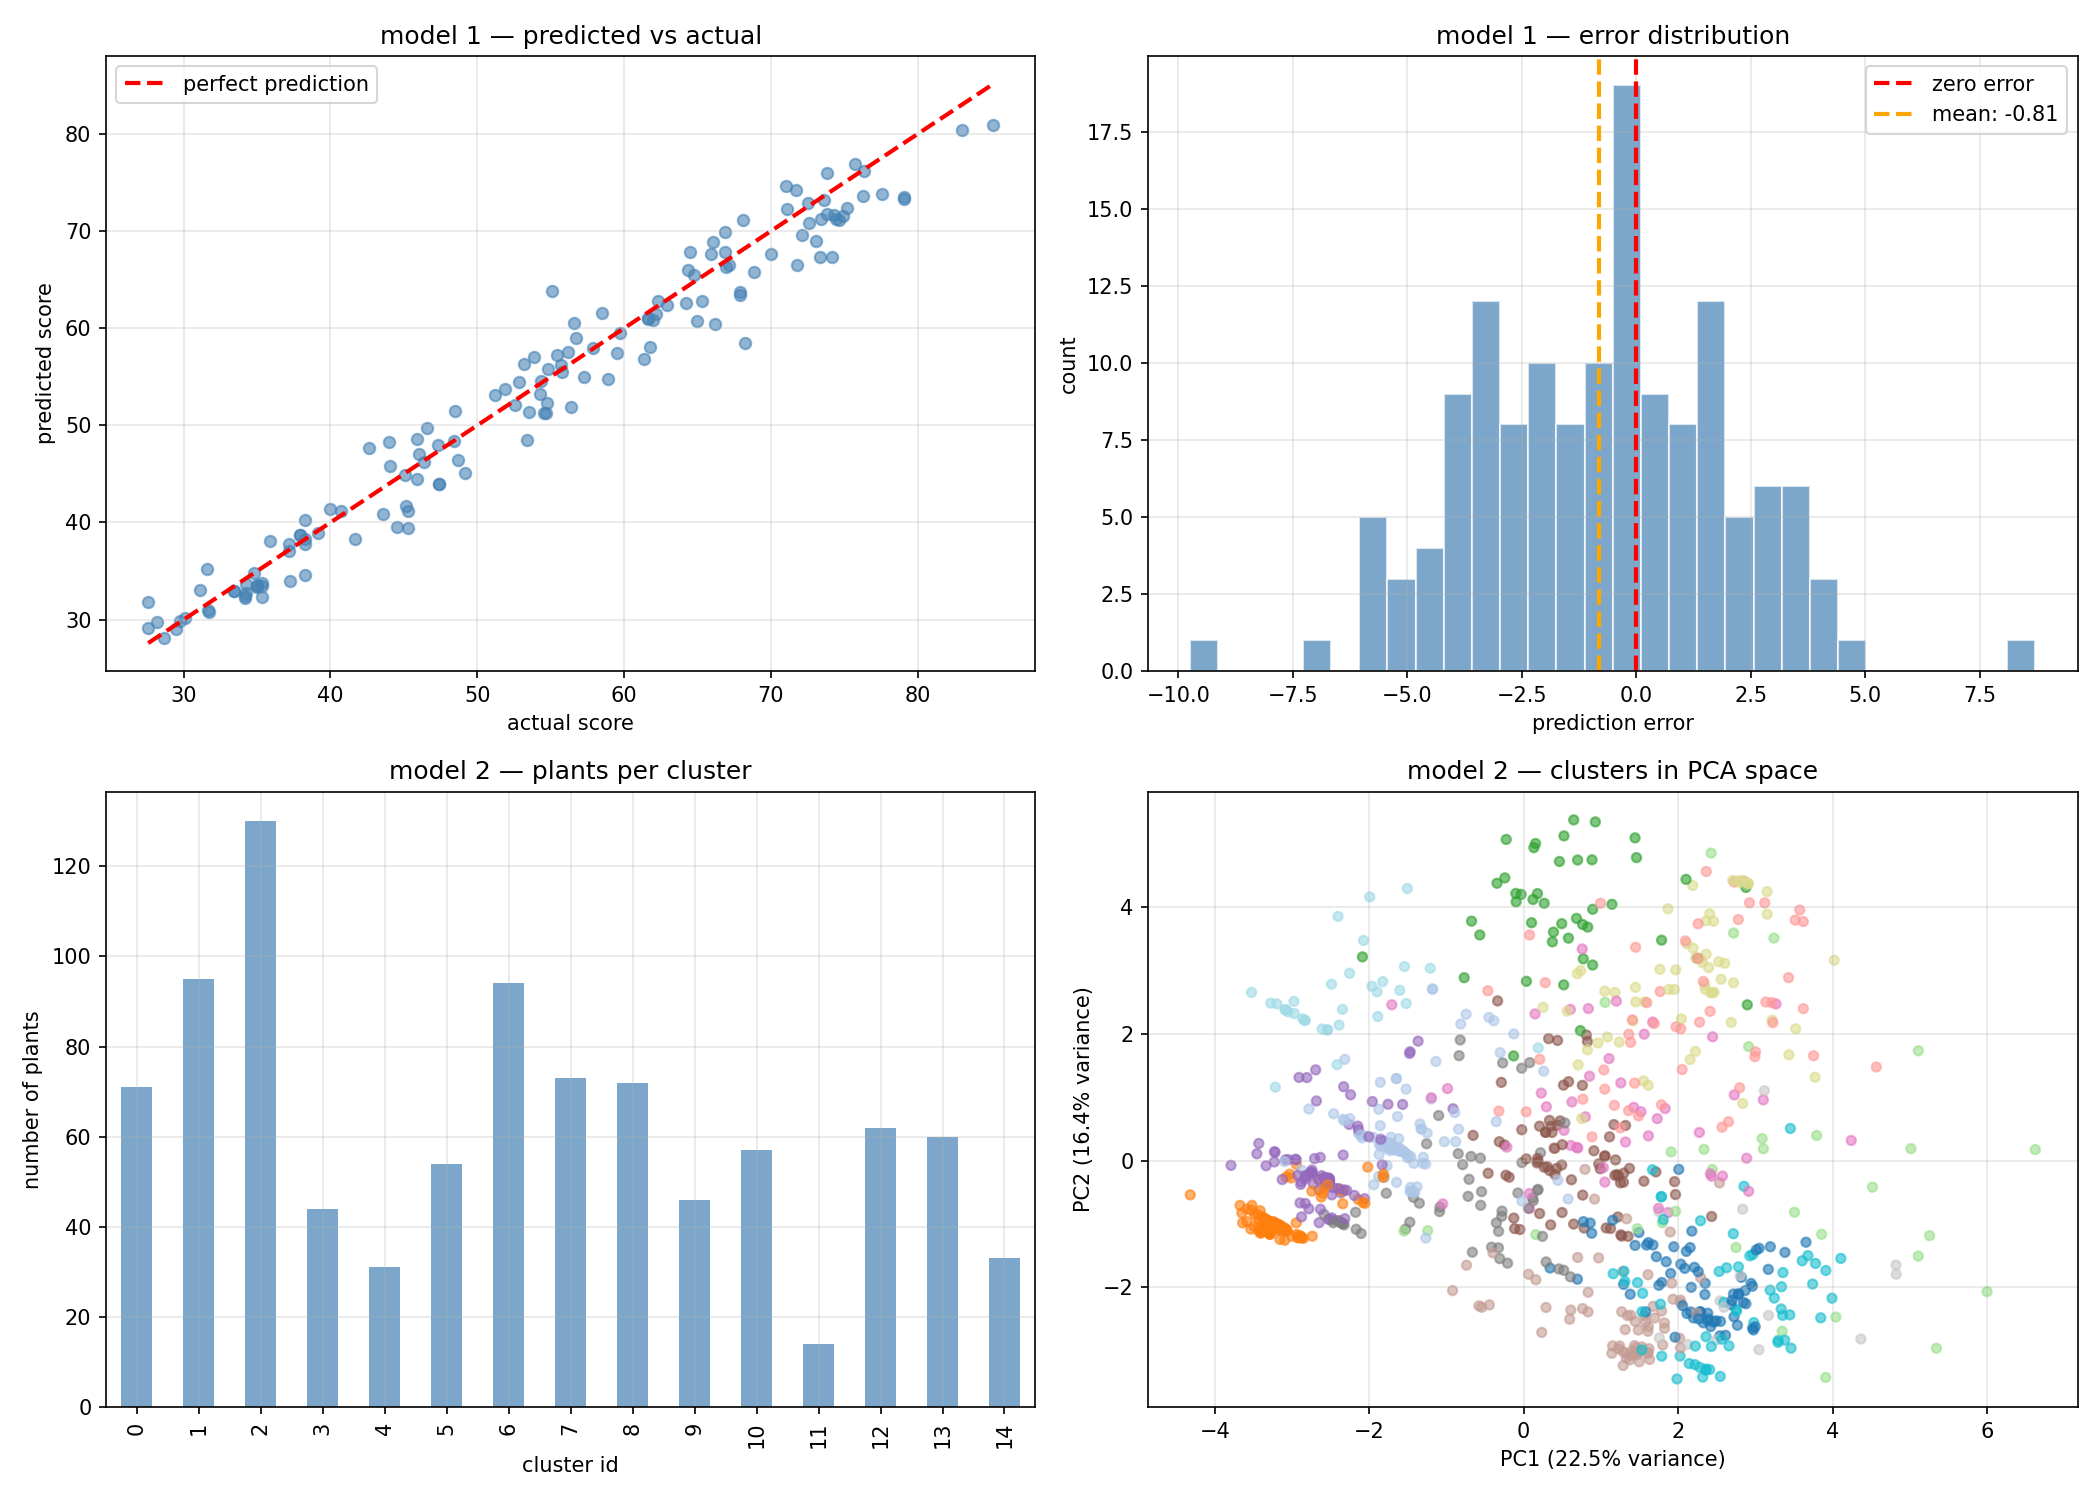

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# model 1 — predicted vs actual
axes[0,0].scatter(y_true, y_pred, alpha=0.6, color='steelblue', s=30)
axes[0,0].plot([y_true.min(), y_true.max()],
               [y_true.min(), y_true.max()],
               'r--', linewidth=2, label='perfect prediction')
axes[0,0].set_xlabel('actual score')
axes[0,0].set_ylabel('predicted score')
axes[0,0].set_title('model 1 — predicted vs actual')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# model 1 — error distribution
errors = y_pred - y_true
axes[0,1].hist(errors, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2, label='zero error')
axes[0,1].axvline(errors.mean(), color='orange', linestyle='--',
                  linewidth=2, label=f'mean: {errors.mean():.2f}')
axes[0,1].set_xlabel('prediction error')
axes[0,1].set_ylabel('count')
axes[0,1].set_title('model 1 — error distribution')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# model 2 — cluster sizes
cluster_sizes.sort_index().plot(kind='bar', ax=axes[1,0],
                                 color='steelblue', alpha=0.7)
axes[1,0].set_xlabel('cluster id')
axes[1,0].set_ylabel('number of plants')
axes[1,0].set_title('model 2 — plants per cluster')
axes[1,0].grid(True, alpha=0.3)

# model 2 — pca visualization of clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sim_scaled)

scatter = axes[1,1].scatter(X_pca[:, 0], X_pca[:, 1],
                             c=labels, cmap='tab20',
                             alpha=0.6, s=20)
axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1,1].set_title('model 2 — clusters in PCA space')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/evaluation_full.png', dpi=150)
plt.show()